# Test sliding window of size N
- does the distribution of the next window of N (i - 99 to i + 1) ever differ from the window of the previous N
- do the subsequent 10 spans ever fall outside the CIs of median E for the prior N spans

# import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import statsmodels.api as sm

from scipy import stats
from scipy.stats import ks_2samp


sns.set_theme(style="whitegrid")

fs=24

## Import data

In [19]:
df_spans_500 = pd.read_csv("../../../Data/E2EGHG/span_500.csv")

In [20]:
df_spans_500

,trace.id,span.id,measurements.count,start_time_us,energy.joules,start.energy.joules,end.energy.joules,epler.duration.ms,kepler.energy.joules,exper_name,cpu_ms,active_interval_ms
0,222f87835be6d5fd5163c0efc6ee7ca7,0fba401994f44764,2,1774508275980213,0.354891,1013.420419,1013.775310,28,0,uniform-a,100,100
1,76bad4ef4b99578975cc03a38983099f,988e64c0db11f61f,2,1774508168464898,0.285905,963.415738,963.701643,27,0,uniform-a,100,100
2,b3a407073d2cac3c0b1f302c4eb356f2,f6200cba4a3fe9c7,2,1774508054979728,0.330809,912.071595,912.402404,28,0,uniform-a,100,100
3,2f382c7721a471041538370db4d53e15,eb258b6dab05d197,2,1774508007189456,0.329298,890.888656,891.217954,28,0,uniform-a,100,100
4,563dd2e8338e1860ff89b4e8af960f83,e71daf18301cd67e,2,1774507925560121,0.392451,854.583754,854.976205,28,0,uniform-a,100,100
...,...,...,...,...,...,...,...,...,...,...,...,...
18995,0b3836f2d83aaf3db16762e46fa5c9b0,e3744c1b29b5645b,8,1774517514170883,2.089440,3963.513137,3965.602577,119,0,uniform-a,500,62
18996,961e134e5e759d6c48e183547628f764,6149e0ae385c4296,8,1774517240417360,1.862854,3383.207707,3385.070561,110,0,uniform-a,500,62
18997,c3f17c9ef9b4e78d946e04460b00ff79,e8cd3649e3f9421e,8,1774517658518987,1.926418,4266.167542,4268.093960,111,0,uniform-a,500,62
18998,cdef1565e8c225e2c2a6d65710ff0cd8,3fd4bd202eff1ccf,8,1774517424573234,1.879143,3773.554981,3775.434124,112,0,uniform-a,500,62


In [3]:
# create reduced dataset for modeling
df = df_spans_1000.drop([ 'samples', 'zone', 'timestamp',
        'kepler_duration_sum_ms_span', 'kepler_energy_joules_span',
         'start_energy_joules_span',
        'end_energy_joules_span', 'start_energy_joules_kepler',
        'end_energy_joules_kepler', 'exper_name', 'interval_ms', 
        'sleep_ms',  'idle_scrapping_ms', 'source_csv'], axis=1)
df.head(10)

,trace_id,energy_joules_span,cpu_ms,active_interval_ms
0,774fea4ae5b4d969b4bf596c6eaf4af0,4.174236,1000,50.000
1,bd22803a5ff6bc7895132e7890138cae,0.880760,150,150.000
2,0b2f77748f51ba2d3f4ef632a9365ad3,0.441735,150,75.000
3,abc243f0e8195d4e5ef242db69fbe9a0,7.793923,2000,50.000
4,3c9bd42a5d09c0f8471db4b31e7cdda7,0.123870,20,0.125
5,afde2ce03d6cc9f302ef16417f0f2e8b,10.768982,2750,68.750
6,02054895ef342c9c3f395ac401485ac1,0.385348,100,25.000
7,63590d0b5518fb051ea292ceda74ace9,0.472778,100,25.000
8,9d3381d559c8e3e41be242cefd0c2c15,1.780661,500,3.125
9,9ad937051ed5fb795c71388b740c224e,0.334675,100,25.000


#### filter out rows with too short active_interval_ms (< 25.0 ms are removed)

In [4]:
df = df.query('active_interval_ms >= 25.0')
df

,trace_id,energy_joules_span,cpu_ms,active_interval_ms
0,774fea4ae5b4d969b4bf596c6eaf4af0,4.174236,1000,50.00
1,bd22803a5ff6bc7895132e7890138cae,0.880760,150,150.00
2,0b2f77748f51ba2d3f4ef632a9365ad3,0.441735,150,75.00
3,abc243f0e8195d4e5ef242db69fbe9a0,7.793923,2000,50.00
5,afde2ce03d6cc9f302ef16417f0f2e8b,10.768982,2750,68.75
...,...,...,...,...
45092,4abf6971cf4256a6028a7d6667746a23,0.897521,250,125.00
45093,7b922ca3da3a636784c4c09e3784c031,9.031293,3000,2250.00
45094,8b6158e90e349f6a6bb9812d4d86da47,0.097086,50,25.00
45095,205b5eb1ff519133eeb6a2a0c1713c7d,0.164841,100,75.00


### Get Median E for each cpu_ms

In [5]:
df_median_e_cpu_1000 = df[['energy_joules_span','cpu_ms']].copy()
df_median_e_cpu_1000 = df_median_e_cpu_1000.groupby(['cpu_ms'], as_index=False).median()
df_median_e_cpu_1000

,cpu_ms,energy_joules_span
0,50,0.128859
1,100,0.285802
2,150,0.455825
3,250,0.844799
4,375,1.329002
5,500,1.819178
6,625,2.282161
7,750,2.829188
8,1000,3.792336
9,1250,4.785089


### add column with median energy for that cpu_ms to each trace_id

In [6]:
cpu_ms_vals = np.unique(df['cpu_ms'])
for i in cpu_ms_vals:
    df.loc[df['cpu_ms'] == i, 'median_energy_cpu_ms'] = df_median_e_cpu_1000[df_median_e_cpu_1000['cpu_ms'] == i].energy_joules_span.values[0]

df.head(10)

,trace_id,energy_joules_span,cpu_ms,active_interval_ms,median_energy_cpu_ms
0,774fea4ae5b4d969b4bf596c6eaf4af0,4.174236,1000,50.00,3.792336
1,bd22803a5ff6bc7895132e7890138cae,0.880760,150,150.00,0.455825
2,0b2f77748f51ba2d3f4ef632a9365ad3,0.441735,150,75.00,0.455825
3,abc243f0e8195d4e5ef242db69fbe9a0,7.793923,2000,50.00,7.795812
5,afde2ce03d6cc9f302ef16417f0f2e8b,10.768982,2750,68.75,10.669263
6,02054895ef342c9c3f395ac401485ac1,0.385348,100,25.00,0.285802
7,63590d0b5518fb051ea292ceda74ace9,0.472778,100,25.00,0.285802
9,9ad937051ed5fb795c71388b740c224e,0.334675,100,25.00,0.285802
10,53ce784698112331713b74d2beee804a,0.444463,100,50.00,0.285802
11,99648071e9c6152e9efb11bf8f8520b2,0.521254,150,25.00,0.455825


Text(0, 0.5, 'Energy')

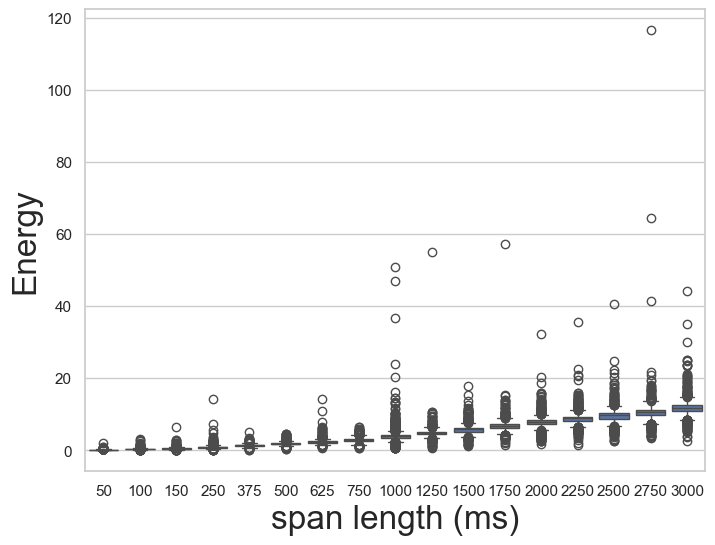

In [14]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='cpu_ms', y='energy_joules_span')#, col='cpu_ms', col_wrap=4, palette='tab10', markers='o', ci=95)
plt.xlabel("span length (ms)", fontsize=fs)
plt.ylabel(r'Energy', fontsize=fs)

### From the "Taming Performance Variability" paper: "compute $\lfloor{\frac{n - z \sqrt{n}}{ 2}}\rfloor$ and $\lceil{1+\frac{n+z \sqrt{n}  }{2} }\rceil$,where n is the number of elements in X, and z is the standard score (or z-score). z depends only on the desired confidence level, and is 1.96 for the commonly-used level of $\alpha = 95\\\%$. These two numbers are then used as indexes into the sorted X: the values at those locations are the top and the bottom bounds of the CI. Note that one of these numbers will be larger than the median (at index n/2) and the other will be smaller, and they will not necessarily be symmetric around the median. These bounds tend to get tighter—to approach the sample mean—with more repetitions. Typically, we are concerned with the relative difference r% between the CI bounds and the mean."

In [7]:
# df['gender'] = df['gender'].apply(lambda x: 0 if x == 'female' else x)

#df_filtered_1000_fixed['sampling_ratio'] = df_filtered_1000_fixed['sampling_ratio'].apply(lambda x: 4.000000 if ((x > 4) & (x < 5)) else x)


#### Build confidence intervals on accuracy per span length and reciprocal sampling ratio

In [9]:
# copy data for experimenting
df_test = df.copy()

In [10]:
span_lengths = np.unique(df_test.cpu_ms)
span_lengths

array([  50,  100,  150,  250,  375,  500,  625,  750, 1000, 1250, 1500,
       1750, 2000, 2250, 2500, 2750, 3000])

In [18]:
# set params for conf intervals calculation
# here using the Z-score for 95% confidence

z = 1.96


temp_df = pd.DataFrame(columns=['n','cpu_ms','median_energy','e_upper_ci','e_lower_ci'])

for span_ms in span_lengths:
    the_n = df_test.query('(cpu_ms == @span_ms)').shape[0]
    lower_ci_idx = int(np.floor((the_n - z*np.sqrt(the_n))/2))
    upper_ci_idx = int(np.ceil(1 + ((the_n + z*np.sqrt(the_n))/2)))
    acc_eng = df_test.query('(cpu_ms == @span_ms)')['energy_joules_span']
    acc_eng_sorted = np.sort(acc_eng)
    acc_eng_upper_ci = acc_eng_sorted[upper_ci_idx]
    acc_eng_lower_ci = acc_eng_sorted[lower_ci_idx]
    temp_df.loc[len(temp_df.index)] = [the_n, span_ms, acc_eng.median(), acc_eng_upper_ci, acc_eng_lower_ci]
        #print(the_n,span_ms,ratio,acc_eng_upper_ci,acc_eng_lower_ci)

temp_df
        

,n,cpu_ms,median_energy,e_upper_ci,e_lower_ci
0,3000.0,50.0,0.128859,0.132034,0.125877
1,4000.0,100.0,0.285802,0.289430,0.282838
2,5000.0,150.0,0.455825,0.459953,0.450637
3,5000.0,250.0,0.844799,0.851131,0.838893
4,500.0,375.0,1.329002,1.357047,1.299444
5,600.0,500.0,1.819178,1.847633,1.797855
6,600.0,625.0,2.282161,2.317366,2.253580
7,600.0,750.0,2.829188,2.866452,2.785119
8,7000.0,1000.0,3.792336,3.806307,3.776391
9,700.0,1250.0,4.785089,4.852042,4.748739


## **** stopped here

### add columns with CI values for that cpu_ms and sampling ratio

In [41]:
cpu_ms_vals = np.unique(df_median_dev_1000['cpu_ms'])
#ratio_vals = np.unique(df_median_dev_1000['recip_sampling_ratio'])

for i in cpu_ms_vals:
    ratio_vals = np.unique(df_median_dev_1000.query('cpu_ms == @i').recip_sampling_ratio)    
    for j in ratio_vals:
        # copy in CI values
        df_median_dev_1000.loc[(df_median_dev_1000['cpu_ms'] == i) & (df_median_dev_1000['recip_sampling_ratio'] == j), 
            'delta_e_upper_ci'] = temp_df[(temp_df['cpu_ms'] == i) & (temp_df['recip_sampling_ratio'] == j)].delta_e_upper_ci.values[0]
        df_median_dev_1000.loc[(df_median_dev_1000['cpu_ms'] == i) & (df_median_dev_1000['recip_sampling_ratio'] == j), 
            'delta_e_lower_ci'] = temp_df[(temp_df['cpu_ms'] == i) & (temp_df['recip_sampling_ratio'] == j)].delta_e_lower_ci.values[0]

df_median_dev_1000.head(10)

,cpu_ms,sampling_ratio,median_energy_deviation,recip_sampling_ratio,delta_e_upper_ci,delta_e_lower_ci
0,50,1.000000,32.310898,1.00,34.930428,30.041363
1,50,1.333333,27.400104,0.75,29.737155,25.596970
2,50,2.000000,32.807953,0.50,34.862136,31.515843
3,100,1.000000,24.012295,1.00,27.147338,22.278924
4,100,1.333333,26.807242,0.75,28.931794,25.537830
5,100,2.000000,17.224892,0.50,18.284894,15.973499
6,100,4.000000,15.325322,0.25,16.908764,14.099121
7,150,1.000000,23.782289,1.00,25.603385,22.165877
8,150,1.333333,27.615014,0.75,29.052738,25.865547
9,150,2.000000,14.991515,0.50,16.200643,14.222031
